In [1]:
import os, glob, math, random
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter, defaultdict

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, ELU
from tensorflow.keras.optimizers import Adagrad
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

In [ ]:
DATA_DIR = Path("OASIS_slices")
CSV_PATH = Path("oasis_longitudinal_demographics.csv")

IMG_SIZE = (256, 256)
INIT_LR = 1e-3
EPOCHS = 100
BATCH_SIZE = 16
TEST_SPLIT = 0.2   # held-out participants (by ID)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

TAB_COLS = ['M/F','Hand','Age','EDUC','SES','MMSE','CDR','eTIV','nWBV','ASF']

In [3]:
# Making sure we only have 1 visit/patient (the first one) + remove converted data types

df_csv = pd.read_csv(CSV_PATH)
df_csv = df_csv.rename(columns=lambda c: c.strip())
df_csv['Subject ID'] = df_csv['Subject ID'].astype(str).str.strip()
df_csv['Group'] = df_csv['Group'].astype(str).str.strip()

# Coerce Visit to numeric; fall back to MR Delay if Visit missing
df_csv['Visit'] = pd.to_numeric(df_csv['Visit'], errors='coerce')
df_csv['MR Delay'] = pd.to_numeric(df_csv['MR Delay'], errors='coerce')

# 2) Choose the "first visit" per patient
#    Rule: sort by Visit (asc), then MR Delay (asc) as a tie-breaker, then MRI ID for determinism.
df_first = (
    df_csv
    .sort_values(['Subject ID', 'Visit', 'MR Delay', 'MRI ID'], ascending=[True, True, True, True])
    .groupby('Subject ID', as_index=False)
    .first()[['Subject ID', 'Group', 'Visit', 'MR Delay'] + TAB_COLS]
    .rename(columns={'Group': 'GroupFirstVisit'})
)

# Remove 'Converted' group if present
df_first = df_first[df_first['GroupFirstVisit'] != 'Converted']

print("Unique groups at first visit:", df_first['GroupFirstVisit'].dropna().unique())
print("Rows after reducing to first visit:", len(df_first))

Unique groups at first visit: ['Nondemented' 'Demented']
Rows after reducing to first visit: 136


In [4]:
# Associating images with patients in demographic csv

from pathlib import Path
import glob

# One image per patient (keeps counts aligned 1:1)
img_rows = []
for pid_dir in sorted(DATA_DIR.iterdir()):
    if not pid_dir.is_dir():
        continue
    pid = pid_dir.name.strip()
    files = []
    for ext in ("*.png", "*.jpg", "*.jpeg"):
        files.extend(glob.glob(str(pid_dir / ext)))
    if not files:
        continue
    img_rows.append({'pid': pid, 'path': sorted(files)[0]})

df_imgs = pd.DataFrame(img_rows)
assert df_imgs['pid'].is_unique, "Expected one image per patient."

# Inner join: only patients present in both CSV and images
df = df_imgs.merge(df_first, left_on='pid', right_on='Subject ID', how='inner').drop(columns=['Subject ID'])

# Map labels
class_names = ['Nondemented', 'Demented']  # groups we care about
label_map = {c: i for i, c in enumerate(class_names)}

unexpected = sorted(set(df['GroupFirstVisit'].dropna()) - set(class_names))
if unexpected:
    raise ValueError(f"Unexpected groups: {unexpected}")

df['label'] = df['GroupFirstVisit'].map(label_map).astype(int)

print("Patients:", df['pid'].nunique(), " Images:", len(df))
print(df['GroupFirstVisit'].value_counts())


Patients: 136  Images: 136
GroupFirstVisit
Nondemented    72
Demented       64
Name: count, dtype: int64


In [5]:
df

,pid,path,GroupFirstVisit,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,label
0,OAS2_0001,OASIS_slices/OAS2_0001/OAS2_0001_axial_p50.png,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883,0
1,OAS2_0002,OASIS_slices/OAS2_0002/OAS2_0002_axial_p50.png,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046,1
2,OAS2_0004,OASIS_slices/OAS2_0004/OAS2_0004_axial_p50.png,Nondemented,1,0,F,R,88,18,3.0,28.0,0.0,1215,0.710,1.444,0
3,OAS2_0005,OASIS_slices/OAS2_0005/OAS2_0005_axial_p50.png,Nondemented,1,0,M,R,80,12,4.0,28.0,0.0,1689,0.712,1.039,0
4,OAS2_0007,OASIS_slices/OAS2_0007/OAS2_0007_axial_p50.png,Demented,1,0,M,R,71,16,NaN,28.0,0.5,1357,0.748,1.293,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,OAS2_0182,OASIS_slices/OAS2_0182/OAS2_0182_axial_p50.png,Demented,1,0,M,R,73,12,NaN,23.0,0.5,1661,0.698,1.056,1
132,OAS2_0183,OASIS_slices/OAS2_0183/OAS2_0183_axial_p50.png,Nondemented,1,0,F,R,66,13,2.0,30.0,0.0,1495,0.746,1.174,0
133,OAS2_0184,OASIS_slices/OAS2_0184/OAS2_0184_axial_p50.png,Demented,1,0,F,R,72,16,3.0,24.0,0.5,1354,0.733,1.296,1
134,OAS2_0185,OASIS_slices/OAS2_0185/OAS2_0185_axial_p50.png,Demented,1,0,M,R,80,16,1.0,28.0,0.5,1704,0.711,1.030,1


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.one_hot(label, depth=len(class_names))

def make_dataset(paths, labels, batch_size, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(10000, len(paths)), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x,y: (tf.image.random_flip_left_right(x, seed=SEED), y), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


In [7]:
# Test/Train Split -> stratified by diagnosis

from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
import pandas as pd

VAL_SPLIT = 0.1   # 10% of trainval becomes validation for early stopping

# patient-level table for splitting
df_pat = df[['pid','label']].drop_duplicates()
X_pid = df_pat['pid'].values
y_pid = df_pat['label'].values

# First: hold-out test split (by patient)
sss_test = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SPLIT, random_state=SEED)
trainval_pid_idx, test_pid_idx = next(sss_test.split(X_pid, y_pid))
trainval_pids = set(X_pid[trainval_pid_idx])
test_pids = set(X_pid[test_pid_idx])

df_trainval = df[df['pid'].isin(trainval_pids)].reset_index(drop=True)
df_test     = df[df['pid'].isin(test_pids)].reset_index(drop=True)

# Second: from trainval, carve out a small validation set (by patient)
df_tv_pat = df_trainval[['pid','label']].drop_duplicates()
X_tv_pid = df_tv_pat['pid'].values
y_tv_pid = df_tv_pat['label'].values

sss_val = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SPLIT, random_state=SEED)
train_pid_idx, val_pid_idx = next(sss_val.split(X_tv_pid, y_tv_pid))
train_pids = set(X_tv_pid[train_pid_idx])
val_pids   = set(X_tv_pid[val_pid_idx])

df_train = df_trainval[df_trainval['pid'].isin(train_pids)].reset_index(drop=True)
df_val   = df_trainval[df_trainval['pid'].isin(val_pids)].reset_index(drop=True)

print("Patients — train/val/test:", df_train['pid'].nunique(), df_val['pid'].nunique(), df_test['pid'].nunique())
print("Images   — train/val/test:", len(df_train), len(df_val), len(df_test))



Patients — train/val/test: 97 11 28
Images   — train/val/test: 97 11 28


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

CAT_COLS = ['M/F', 'Hand']
NUM_COLS = [c for c in TAB_COLS if c not in CAT_COLS]

# build patient-level splits (already in your code)
# df_train, df_val, df_test exist here

# sklearn preprocessing pipelines
cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preproc = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, CAT_COLS),
        ('num', num_pipe, NUM_COLS)
    ],
    remainder='drop'
)

# fit on TRAIN ONLY
preproc.fit(df_train[TAB_COLS])

# transform to numpy arrays
X_train_tab = preproc.transform(df_train[TAB_COLS]).astype('float32')
X_val_tab   = preproc.transform(df_val[TAB_COLS]).astype('float32')
X_test_tab  = preproc.transform(df_test[TAB_COLS]).astype('float32')

TAB_DIM = X_train_tab.shape[1]
print("Tabular feature dim:", TAB_DIM)


Tabular feature dim: 11


In [9]:
def make_mm_dataset(paths, tab, labels, batch_size, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, tab, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(10000, len(paths)), seed=SEED, reshuffle_each_iteration=True)
    def _load(path, t, y):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        if augment:
            img = tf.image.random_flip_left_right(img, seed=SEED)
        return (img, t), tf.one_hot(y, depth=len(class_names))
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


In [10]:
X_train_paths = df_train['path'].values
y_train = df_train['label'].values
X_val_paths = df_val['path'].values
y_val = df_val['label'].values
X_test_paths = df_test['path'].values
y_test = df_test['label'].values

train_ds = make_mm_dataset(df_train['path'].values, X_train_tab, df_train['label'].values,
                           BATCH_SIZE, shuffle=True, augment=True)
val_ds   = make_mm_dataset(df_val['path'].values,   X_val_tab,   df_val['label'].values,
                           BATCH_SIZE, shuffle=False, augment=False)
test_ds  = make_mm_dataset(df_test['path'].values,  X_test_tab,  df_test['label'].values,
                           BATCH_SIZE, shuffle=False, augment=False)


In [11]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Concatenate

def build_mm_model(tab_dim):
    # --- image branch ---
    conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    for layer in conv_base.layers:
        layer.trainable = False

    img_in = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name='image')
    x = conv_base(img_in, training=False)
    x = Flatten()(x)
    x = Dense(128, activation='linear')(x)
    x = ELU()(x)
    x = Dropout(0.5)(x)

    # --- tabular branch ---
    tab_in = Input(shape=(tab_dim,), name='tabular')
    t = Dense(64, activation='relu')(tab_in)
    t = Dropout(0.2)(t)
    t = Dense(32, activation='relu')(t)

    # --- fuse ---
    h = Concatenate()([x, t])
    h = Dense(64, activation='relu')(h)
    h = Dropout(0.4)(h)
    out = Dense(len(class_names), activation='softmax')(h)

    model = Model(inputs=[img_in, tab_in], outputs=out)

    opt = Adagrad(learning_rate=INIT_LR, decay=INIT_LR/100.0)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=opt,
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc', multi_label=False),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

model = build_mm_model(TAB_DIM)
model.summary()


/opt/anaconda3/envs/Deskilling/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 8, 8, 512) │ 14,714,688 │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32768)     │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular             │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │  4,194,432 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        768 │ tabular[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ elu (ELU)           │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ elu[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │     10,304 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 2)         │        130 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,922,402 (72.18 MB)

 Trainable params: 4,207,714 (16.05 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [17]:
# Model Training!

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np

# class weights for imbalance
cls_w = compute_class_weight(class_weight='balanced',
                             classes=np.arange(len(class_names)),
                             y=y_train)
class_weight_dict = {i: w for i, w in enumerate(cls_w)}
print("Class weights:", class_weight_dict)

model = build_mm_model(TAB_DIM)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint("best_single_split.keras", monitor='val_loss', save_best_only=True, verbose=1)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    verbose=1,
    #callbacks=callbacks
)

Class weights: {0: np.float64(0.9509803921568627), 1: np.float64(1.0543478260869565)}
Epoch 1/100


/opt/anaconda3/envs/Deskilling/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 627ms/step - accuracy: 0.4812 - auc: 0.4729 - loss: 0.9855 - precision: 0.4812 - recall: 0.4812 - val_accuracy: 0.4545 - val_auc: 0.3388 - val_loss: 0.7543 - val_precision: 0.4545 - val_recall: 0.4545
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 660ms/step - accuracy: 0.4948 - auc: 0.4722 - loss: 1.0130 - precision: 0.4948 - recall: 0.4948 - val_accuracy: 0.5455 - val_auc: 0.5950 - val_loss: 0.6995 - val_precision: 0.5455 - val_recall: 0.5455
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 611ms/step - accuracy: 0.5745 - auc: 0.5833 - loss: 0.7679 - precision: 0.5745 - recall: 0.5745 - val_accuracy: 0.5455 - val_auc: 0.5041 - val_loss: 0.8246 - val_precision: 0.5455 - val_recall: 0.5455
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 626ms/step - accuracy: 0.4553 - auc: 0.4102 - loss: 0.9979 - precision: 0.4553 - recall: 0.4553 - val_accuracy: 0.5455 - val_auc: 0.3967 - val_loss: 0.7217 - val_precision: 0.5455 - val_recall: 0.5455
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 697ms/st

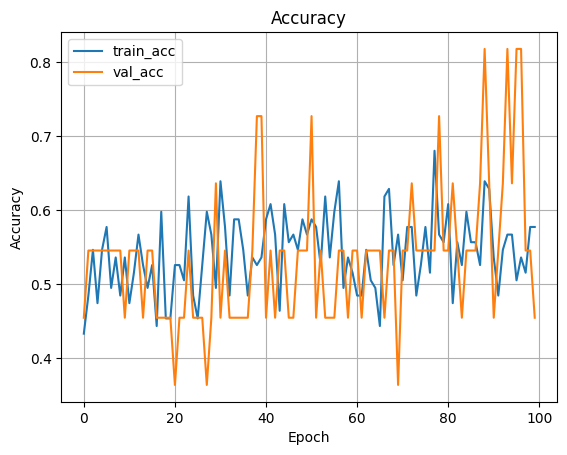

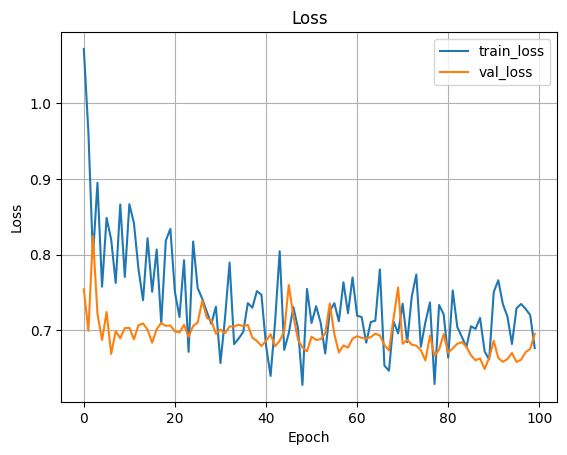

In [18]:
# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()


In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_and_plot(model, dataset, y_true, classes, split_name=""):
    # 1. predictions
    y_pred = np.argmax(model.predict(dataset, verbose=0), axis=1)

    # 2. confusion matrix (counts)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes,
                cbar=False, square=True)
    plt.title(f"{split_name} Confusion Matrix (Counts)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    # 3. normalized confusion matrix (row-wise percentages)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=classes, yticklabels=classes,
                cbar=False, square=True, vmin=0, vmax=1)
    plt.title(f"{split_name} Confusion Matrix (Normalized)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    # 4. classification report
    print(f"\n{split_name} Classification Report:\n",
          classification_report(y_true, y_pred, target_names=classes, digits=4))

    return y_pred, cm


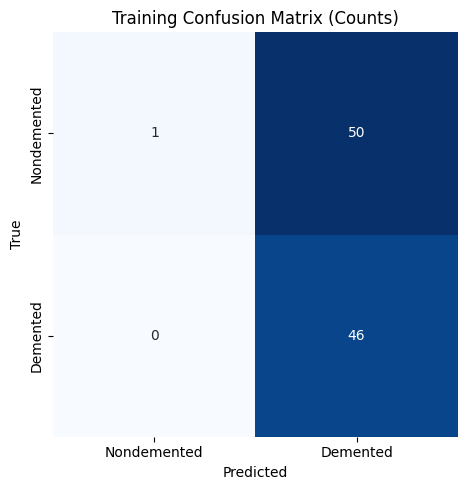

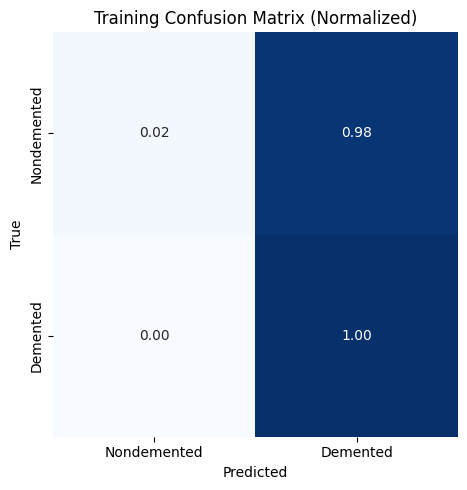


Training Classification Report:
               precision    recall  f1-score   support

 Nondemented     1.0000    0.0196    0.0385        51
    Demented     0.4792    1.0000    0.6479        46

    accuracy                         0.4845        97
   macro avg     0.7396    0.5098    0.3432        97
weighted avg     0.7530    0.4845    0.3275        97



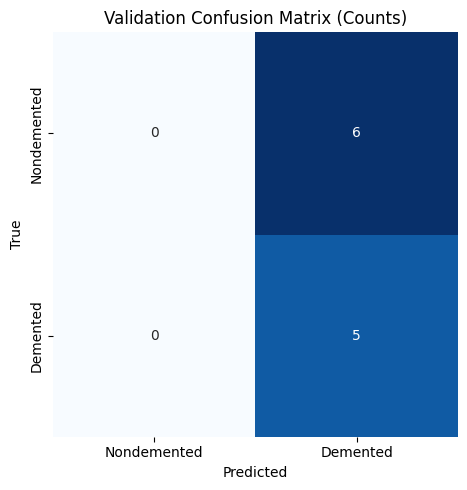

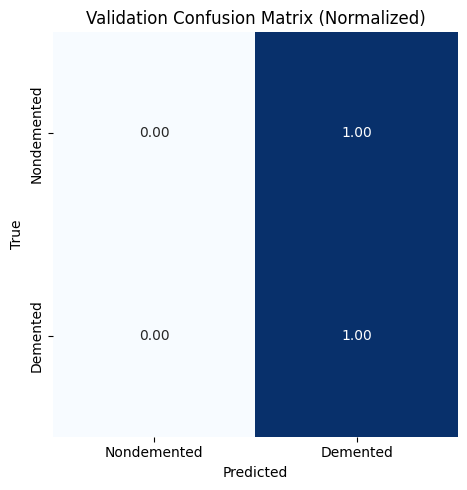

/opt/anaconda3/envs/Deskilling/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/Deskilling/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/Deskilling/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}


Validation Classification Report:
               precision    recall  f1-score   support

 Nondemented     0.0000    0.0000    0.0000         6
    Demented     0.4545    1.0000    0.6250         5

    accuracy                         0.4545        11
   macro avg     0.2273    0.5000    0.3125        11
weighted avg     0.2066    0.4545    0.2841        11



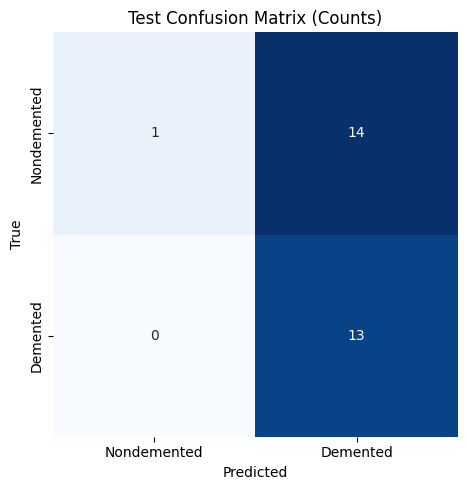

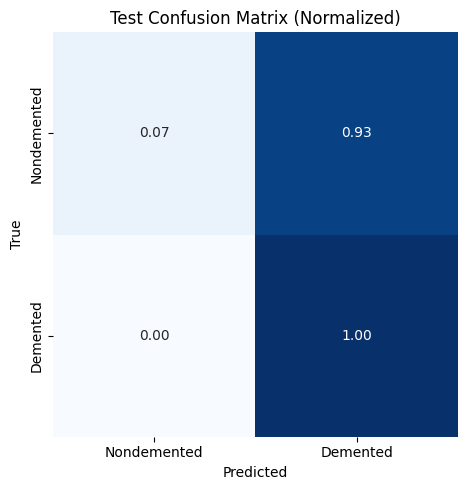


Test Classification Report:
               precision    recall  f1-score   support

 Nondemented     1.0000    0.0667    0.1250        15
    Demented     0.4815    1.0000    0.6500        13

    accuracy                         0.5000        28
   macro avg     0.7407    0.5333    0.3875        28
weighted avg     0.7593    0.5000    0.3688        28



In [20]:
# Build "no-augment" full datasets for eval
train_all_ds = make_mm_dataset(df_train['path'].values, X_train_tab, df_train['label'].values,
                               BATCH_SIZE, shuffle=False, augment=False)
val_all_ds   = make_mm_dataset(df_val['path'].values,   X_val_tab,   df_val['label'].values,
                               BATCH_SIZE, shuffle=False, augment=False)
test_all_ds  = make_mm_dataset(df_test['path'].values,  X_test_tab,  df_test['label'].values,
                               BATCH_SIZE, shuffle=False, augment=False)

y_train_pred, cm_train = evaluate_and_plot(model, train_all_ds, df_train['label'].values, class_names, split_name="Training")
y_val_pred,   cm_val   = evaluate_and_plot(model, val_all_ds,   df_val['label'].values,   class_names, split_name="Validation")
y_test_pred,  cm_test  = evaluate_and_plot(model, test_all_ds,  df_test['label'].values,  class_names, split_name="Test")
